In [83]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [84]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from itertools import combinations

In [85]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

C = {
    'primary':   '#4361EE',
    'secondary': '#3A0CA3',
    'accent':    '#F72585',
    'teal':      '#4CC9F0',
    'green':     '#06D6A0',
    'orange':    '#FB8500',
    'yellow':    '#FFD166',
    'red':       '#EF233C',
    'purple':    '#7209B7',
    'gray':      '#6C757D',
    'light':     '#F8F9FA',
    'dark':      '#1A1A2E',
}
ROLE_PALETTE = {
    'Developer, full-stack':                      '#4361EE',
    'Developer, back-end':                        '#3A0CA3',
    'Developer, front-end':                       '#7209B7',
    'AI/ML engineer':                             '#F72585',
    'Data scientist':                             '#FB8500',
    'Data engineer':                              '#FFD166',
    'Developer, mobile':                          '#06D6A0',
    'DevOps engineer or professional':            '#4CC9F0',
    'Developer, embedded applications or devices':'#EF233C',
    'Cloud infrastructure engineer':              '#6C757D',
}

FIGURE_DPI = 130
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#FAFAFA',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'axes.grid.axis':    'y',
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
})

# **Load Dataset**

In [86]:
dataset_dir = '/content/drive/MyDrive/CareerSegmentation/Dataset'

parts = []
for i in range(1, 7):
    path = f'{dataset_dir}/part_{i}_SO_survey.csv'
    try:
        df_part = pd.read_csv(path, low_memory=False)
        df_part['_source_part'] = i
        parts.append(df_part)
        print(f"Part {i}: {df_part.shape[0]:,} rows")
    except FileNotFoundError:
        print(f"Part {i}: file not found")

df = pd.concat(parts, ignore_index=True)
print(f"\nTotal rows loaded : {len(df):,}")
print(f"Total columns     : {df.shape[1]}")
print(f"Unique respondents: {df['ResponseId'].nunique():,}")

Part 1: 8,117 rows
Part 2: 8,163 rows
Part 3: 8,182 rows
Part 4: 8,156 rows
Part 5: 8,243 rows
Part 6: 8,330 rows

Total rows loaded : 49,191
Total columns     : 173
Unique respondents: 49,191


# **EDA**

## Profil Responden

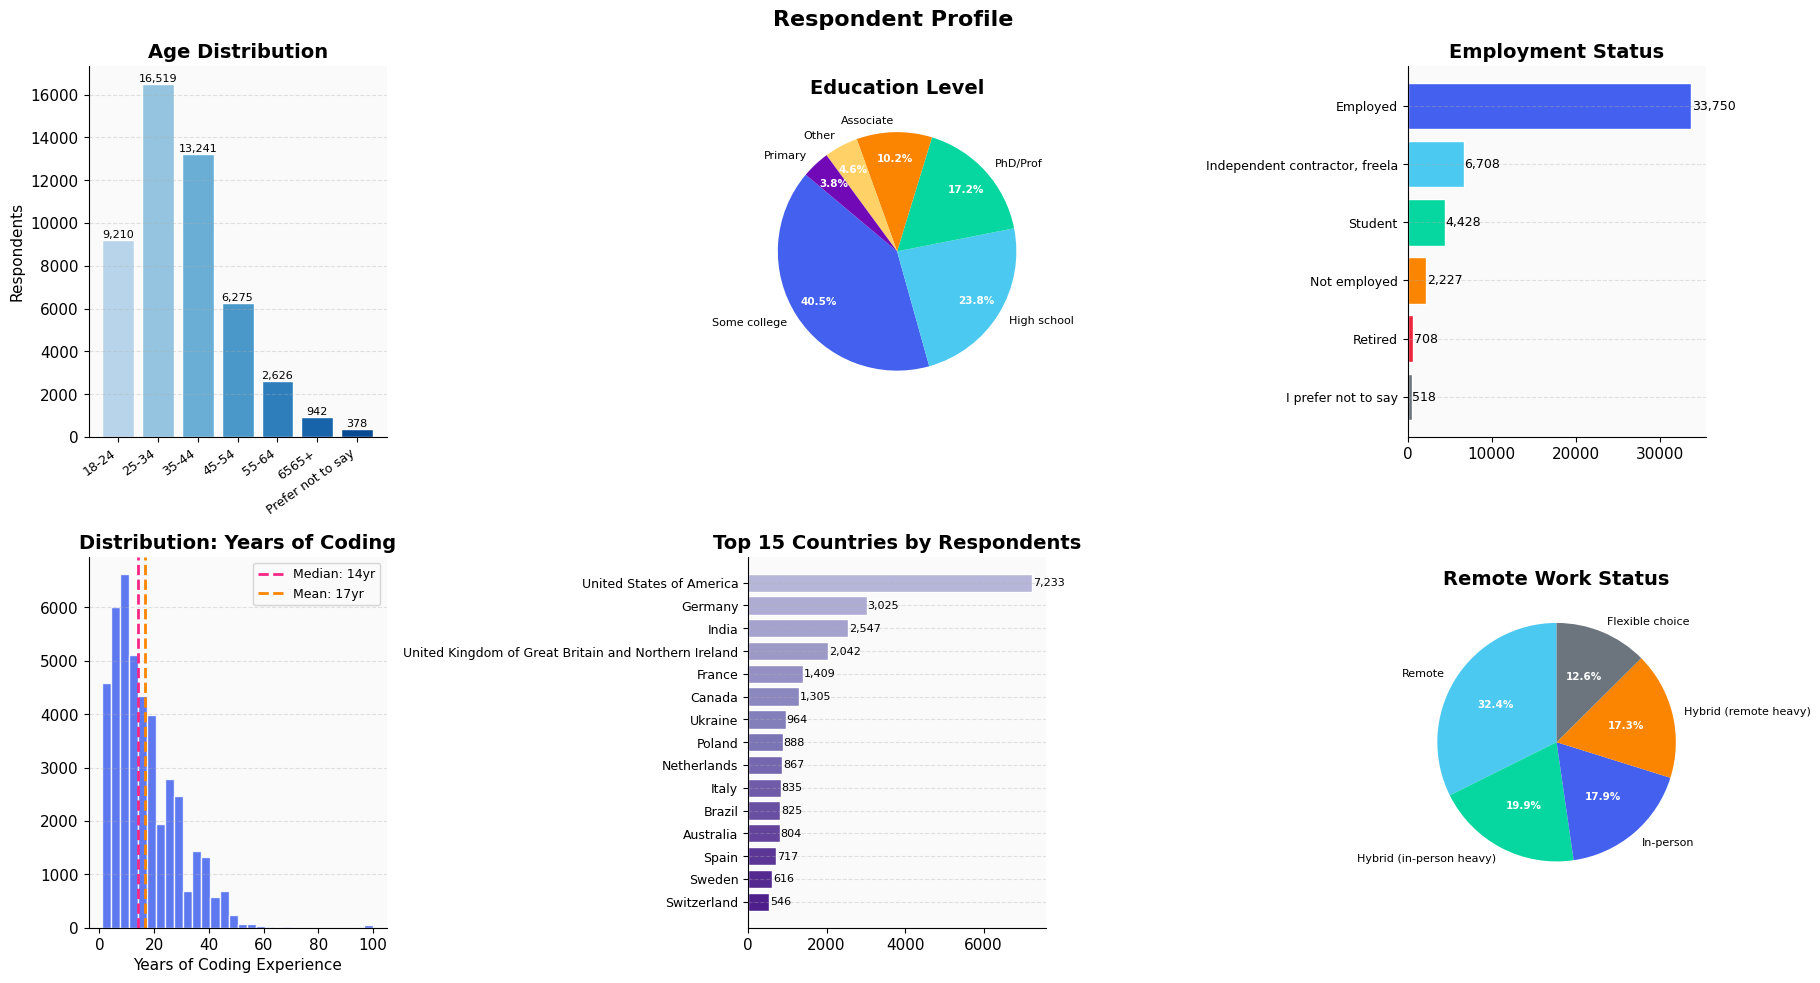

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Respondent Profile', fontsize=16, fontweight='bold')

# 1. Age distribution
ax = axes[0, 0]
age_order = ['Under 18 years old','18-24 years old','25-34 years old',
             '35-44 years old','45-54 years old','55-64 years old',
             '65 years or older','Prefer not to say']
age_counts = df['Age'].value_counts()
age_counts = age_counts.reindex([a for a in age_order if a in age_counts.index])
bars = ax.bar(range(len(age_counts)), age_counts.values,
              color=plt.cm.Blues(np.linspace(0.3, 0.9, len(age_counts))),
              edgecolor='white')
ax.set_xticks(range(len(age_counts)))
ax.set_xticklabels([a.replace(' years old','').replace(' years or older','65+')
                    for a in age_counts.index], rotation=35, ha='right', fontsize=9)
ax.set_title('Age Distribution')
ax.set_ylabel('Respondents')
for bar, val in zip(bars, age_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontsize=8)

# 2. Education level
ax = axes[0, 1]
ed_map = {
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": "Bachelor's",
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's",
    "Some college/university study without earning a degree": "Some college",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "PhD/Prof",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "High school",
    "Associate degree (A.A., A.S., etc.)": "Associate",
    "Primary/elementary school": "Primary",
    "Other (please specify):": "Other",
}
ed_counts = df['EdLevel'].map(ed_map).value_counts()
colors_ed = [C['primary'], C['teal'], C['green'], C['orange'],
             C['yellow'], C['purple'], C['red'], C['gray']]
wedges, texts, autotexts = ax.pie(
    ed_counts.values, labels=ed_counts.index,
    colors=colors_ed[:len(ed_counts)],
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.78, textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontsize(7.5)
    at.set_color('white')
    at.set_fontweight('bold')
ax.set_title('Education Level')

# 3. Employment status
ax = axes[0, 2]
emp_counts = df['Employment'].value_counts().head(6)
emp_labels = [e[:30] for e in emp_counts.index]
ax.barh(range(len(emp_counts)), emp_counts.values,
        color=[C['primary'], C['teal'], C['green'], C['orange'], C['red'], C['gray']],
        edgecolor='white')
ax.set_yticks(range(len(emp_counts)))
ax.set_yticklabels(emp_labels, fontsize=9)
ax.set_title('Employment Status')
ax.invert_yaxis()
for i, val in enumerate(emp_counts.values):
    ax.text(val + 50, i, f'{val:,}', va='center', fontsize=9)

# 4. YearsCode distribution
ax = axes[1, 0]
yc = df['YearsCode'].dropna()
ax.hist(yc, bins=30, color=C['primary'], edgecolor='white', alpha=0.85)
ax.axvline(yc.median(), color=C['accent'], lw=2, ls='--', label=f'Median: {yc.median():.0f}yr')
ax.axvline(yc.mean(),   color=C['orange'], lw=2, ls='--', label=f'Mean: {yc.mean():.0f}yr')
ax.set_xlabel('Years of Coding Experience')
ax.set_title('Distribution: Years of Coding')
ax.legend(fontsize=9)

# 5. Top 15 countries
ax = axes[1, 1]
top_countries = df['Country'].value_counts().head(15)
ax.barh(range(len(top_countries)), top_countries.values,
        color=plt.cm.Purples(np.linspace(0.4, 0.9, len(top_countries))),
        edgecolor='white')
ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels(top_countries.index, fontsize=9)
ax.invert_yaxis()
ax.set_title('Top 15 Countries by Respondents')
for i, val in enumerate(top_countries.values):
    ax.text(val + 20, i, f'{val:,}', va='center', fontsize=8)

# 6. Remote work
ax = axes[1, 2]
rw_counts = df['RemoteWork'].value_counts()
rw_short = {
    'Remote': 'Remote',
    'Hybrid (some remote, leans heavy to in-person)': 'Hybrid (in-person heavy)',
    'Hybrid (some in-person, leans heavy to flexibility)': 'Hybrid (remote heavy)',
    'In-person': 'In-person',
    'Your choice (very flexible, you can come in when you want or just as needed)': 'Flexible choice',
}
rw_counts.index = [rw_short.get(x, x[:30]) for x in rw_counts.index]
wedges2, texts2, auto2 = ax.pie(
    rw_counts.values, labels=rw_counts.index,
    colors=[C['teal'], C['green'], C['primary'], C['orange'], C['gray']],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 8}
)
for at in auto2:
    at.set_fontsize(7.5)
    at.set_fontweight('bold')
    at.set_color('white')
ax.set_title('Remote Work Status')

plt.tight_layout()
plt.show()

Mayoritas responden:
- berasal dari USA
- berusia 25-34 tahun
- berpendidikan S1/S2
- memiliki pengalaman coding (median 14 tahun, mean 17 tahun)
- dan bekerja secara remote.


## Distribusi Developer Roles

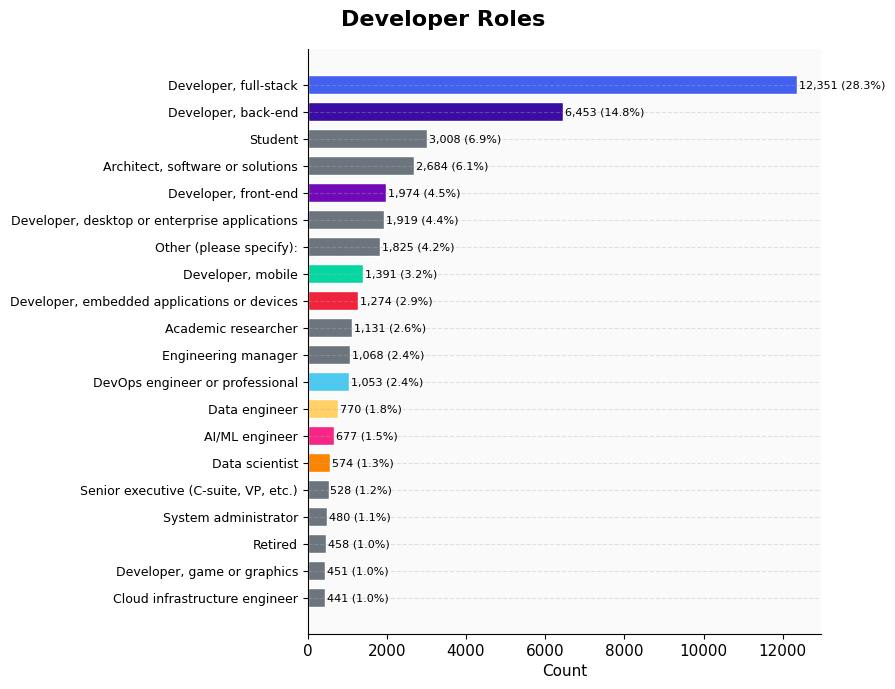

In [88]:
devtype_flat = Counter()
for v in df['DevType'].dropna():
    for d in v.split(';'):
        devtype_flat[d.strip()] += 1


fig, axes = plt.subplots(1, 1, figsize=(9, 7))
fig.suptitle('Developer Roles', fontsize=16, fontweight='bold')

# Left: all DevType roles
ax = axes
top_devtypes = dict(sorted(devtype_flat.items(), key=lambda x: -x[1])[:20])
dt_keys = list(top_devtypes.keys())
dt_vals = list(top_devtypes.values())
total = df['DevType'].notna().sum()
colors_dt = [ROLE_PALETTE.get(k, C['gray']) for k in dt_keys]
bars = ax.barh(range(len(dt_keys)), dt_vals, color=colors_dt, edgecolor='white', height=0.7)
ax.set_yticks(range(len(dt_keys)))
ax.set_yticklabels([k[:45] for k in dt_keys], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Count')
for bar, val in zip(bars, dt_vals):
    pct = val / total * 100
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=8)

plt.tight_layout()
plt.show()

Developer Full-stack mendominasi 28.3% dari total data. Ini menunjukkan terdapat masalah dataset imbalanced.

## Dataset columns

In [89]:
dataset_columns = df.columns.tolist()
for i, col in enumerate(dataset_columns):
  print(f'{i+1}. {col}')

1. ResponseId
2. MainBranch
3. Age
4. EdLevel
5. Employment
6. EmploymentAddl
7. WorkExp
8. LearnCodeChoose
9. LearnCode
10. LearnCodeAI
11. AILearnHow
12. YearsCode
13. DevType
14. OrgSize
15. ICorPM
16. RemoteWork
17. PurchaseInfluence
18. TechEndorseIntro
19. TechEndorse_1
20. TechEndorse_2
21. TechEndorse_3
22. TechEndorse_4
23. TechEndorse_5
24. TechEndorse_6
25. TechEndorse_7
26. TechEndorse_8
27. TechEndorse_9
28. TechEndorse_13
29. TechEndorse_13_TEXT
30. TechOppose_1
31. TechOppose_2
32. TechOppose_3
33. TechOppose_5
34. TechOppose_7
35. TechOppose_9
36. TechOppose_11
37. TechOppose_13
38. TechOppose_16
39. TechOppose_15
40. TechOppose_15_TEXT
41. Industry
42. JobSatPoints_1
43. JobSatPoints_2
44. JobSatPoints_3
45. JobSatPoints_4
46. JobSatPoints_5
47. JobSatPoints_6
48. JobSatPoints_7
49. JobSatPoints_8
50. JobSatPoints_9
51. JobSatPoints_10
52. JobSatPoints_11
53. JobSatPoints_13
54. JobSatPoints_14
55. JobSatPoints_15
56. JobSatPoints_16
57. JobSatPoints_15_TEXT
58. AIThre

Dataset memiliki banyak kolom/fitur, namun projek ini hanya akan menggunakan beberapa fitur yang merepresentasikan skill developer yaitu:
1. LanguageHaveWorkedWith
2. WebFrameHaveWorkedWith
3. DatabaseHaveWorkedWith
4. PlatformHaveWorkedWith
5. DevEnvsHaveWorkedWith
6. AIModelsHaveWorkedWith
7. ConvertedCompYearly (Gaji sebagai output insight)

## Mising Value

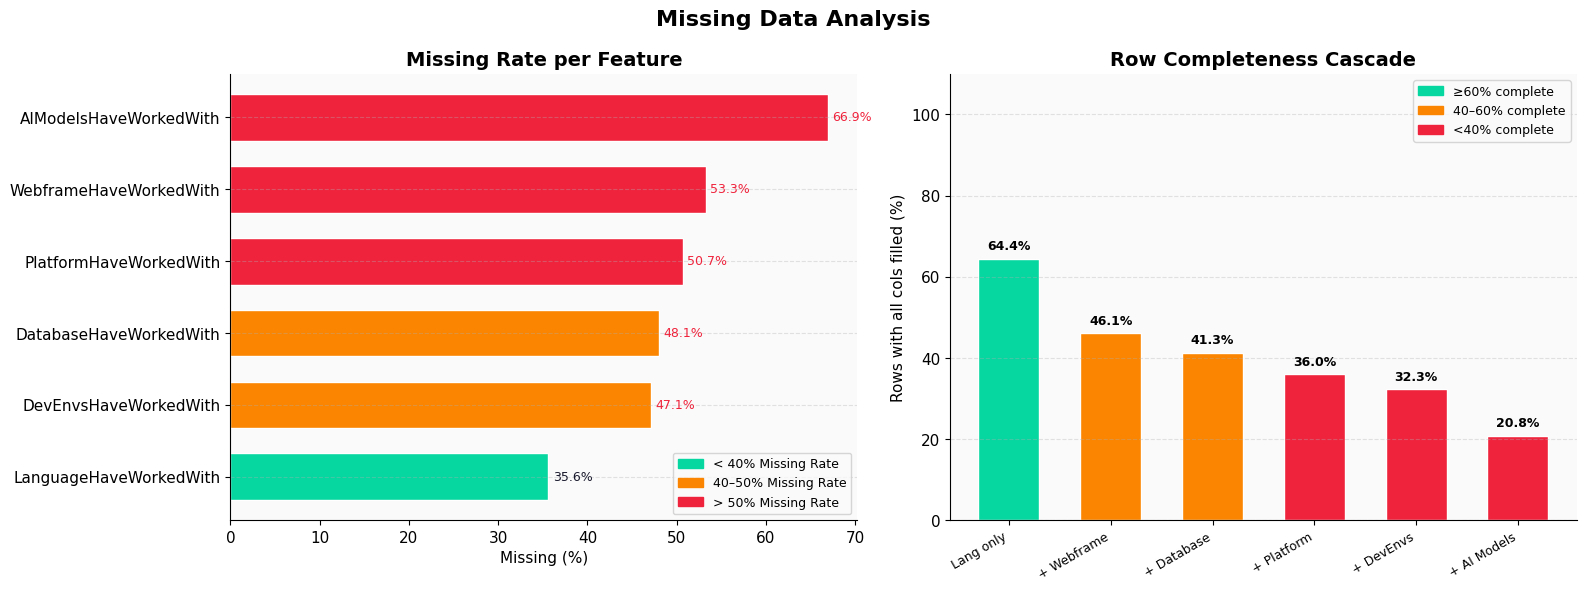

In [90]:
cols = [
    'LanguageHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'DevEnvsHaveWorkedWith',
    'AIModelsHaveWorkedWith',
]

missing_percentage = (df[cols].isna().mean() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Missing Data Analysis', fontsize=16, fontweight='bold')

# Missing rate
ax = axes[0]
colors = [C['red'] if p > 50 else C['orange'] if p > 40 else C['green'] for p in missing_percentage]
bars = ax.barh(missing_percentage.index, missing_percentage.values, color=colors, edgecolor='white', height=0.65)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Rate per Feature')
ax.invert_yaxis()
for bar, val in zip(bars, missing_percentage.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9,
            color=C['red'] if val > 40 else C['dark'])
legend_patches = [
    mpatches.Patch(color=C['green'],  label='< 40% Missing Rate'),
    mpatches.Patch(color=C['orange'], label='40–50% Missing Rate'),
    mpatches.Patch(color=C['red'],    label='> 50% Missing Rate'),
]
ax.legend(handles=legend_patches, fontsize=9)

# Feature Completeness
ax2 = axes[1]
combos = [
    ('Lang only',               ['LanguageHaveWorkedWith']),
    ('+ Webframe',              ['LanguageHaveWorkedWith','WebframeHaveWorkedWith']),
    ('+ Database',              ['LanguageHaveWorkedWith','WebframeHaveWorkedWith','DatabaseHaveWorkedWith']),
    ('+ Platform',              ['LanguageHaveWorkedWith','WebframeHaveWorkedWith','DatabaseHaveWorkedWith','PlatformHaveWorkedWith']),
    ('+ DevEnvs',               ['LanguageHaveWorkedWith','WebframeHaveWorkedWith','DatabaseHaveWorkedWith','PlatformHaveWorkedWith','DevEnvsHaveWorkedWith']),
    ('+ AI Models',             ['LanguageHaveWorkedWith','WebframeHaveWorkedWith','DatabaseHaveWorkedWith','PlatformHaveWorkedWith','DevEnvsHaveWorkedWith','AIModelsHaveWorkedWith']),
]
labels = [c[0] for c in combos]
pcts   = [df[c[1]].notna().all(axis=1).mean()*100 for c in combos]
bar_colors = [C['green'] if p >= 60 else C['orange'] if p >= 40 else C['red'] for p in pcts]
bars2 = ax2.bar(range(len(labels)), pcts, color=bar_colors, edgecolor='white', width=0.6)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Rows with all cols filled (%)')
ax2.set_title('Row Completeness Cascade')
ax2.set_ylim(0, 110)
for bar, val in zip(bars2, pcts):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
legend_patches = [
    mpatches.Patch(color=C['green'],  label='≥60% complete'),
    mpatches.Patch(color=C['orange'], label='40–60% complete'),
    mpatches.Patch(color=C['red'],    label='<40% complete'),
]
ax2.legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.show()

Fitur AIModelsHaveWorkedWith memiliki missing rate paling besar, maka dari itu fitur ini akan di digunakan sebagai fitur tambahan. Fitur lain dengan missing rate dibawah 50% fitur inti, dan untuk fitur LanguageHaveWorkedWith dengan missing rate terendah akan digunakan sebagai fitur utama.

Selain itu, tidak semua responden mengisi semua fitur-fiturnya, sehingga diperlukan preprocessing untuk mengatasi masalah feature incompleteness ini.

## Unique Values & Sparsity

In [91]:
from collections import defaultdict

feature_cols = [
  'LanguageHaveWorkedWith',
  'WebframeHaveWorkedWith',
  'DatabaseHaveWorkedWith',
  'PlatformHaveWorkedWith',
  'DevEnvsHaveWorkedWith',
  'AIModelsHaveWorkedWith',
]

feature_detail = defaultdict(list)
total_unique_values = 0

print('Total Unique Values for each Selected Feature:')

for col in feature_cols:
  exploded_data = df[col].str.split(';').explode()
  exploded_data = exploded_data.str.strip()

  unique_values = exploded_data.nunique()
  total_unique_values += unique_values
  print(f"  - {col} : {unique_values} unique values")

  unique_details = exploded_data.unique()
  feature_detail[col] = unique_details

print(f'\nTotal unique values for all selected features: {total_unique_values}')

Total Unique Values for each Selected Feature:
  - LanguageHaveWorkedWith : 42 unique values
  - WebframeHaveWorkedWith : 28 unique values
  - DatabaseHaveWorkedWith : 30 unique values
  - PlatformHaveWorkedWith : 42 unique values
  - DevEnvsHaveWorkedWith : 27 unique values
  - AIModelsHaveWorkedWith : 17 unique values

Total unique values for all selected features: 186


In [92]:
encoded_dfs = []

for col in feature_cols:
    df_col_encoded = df[col].fillna('').str.get_dummies(sep=';')
    encoded_dfs.append(df_col_encoded)

df_encoded = pd.concat(encoded_dfs, axis=1)

# Active Features per Respondent
active_per_respondent = df_encoded.sum(axis=1)
active_mean = active_per_respondent.mean()

print(f"Active Features per Respondent:")
print(f'Sparsity  : {(1 - (active_mean/total_unique_values))*100:.2f}%')
print(f"Mean      : {active_mean:.0f} dari {total_unique_values} fitur aktif per responden.")

Active Features per Respondent:
Sparsity  : 92.39%
Mean      : 14 dari 186 fitur aktif per responden.


Setelah melakukan Multi Hot Binary Encoding pada fitur yang dipilih, didapatkan total 186 total binary features, dengan sparsity mencapai 92.39%. Ini akan menyebabkan masalah *Curse of Dimensionality* dan membuat euclidean distance kurang efektif. Maka dari itu, dimensionality reduction wajib dilakukan sebelum melakukan clustering menggunakan K-Means.